In [33]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [34]:
# Read in CSV
zillow_quarterly_df = pd.read_csv("Resources/zillow_quarterly.csv", index_col=0)
zillow_quarterly_df.head()

,RegionID,Neighborhood,City,Year,Quarter,Avg Annual Home Value
0,6018,Montbello,Denver,2000,1,127119.42
1,6018,Montbello,Denver,2000,2,131496.90
2,6018,Montbello,Denver,2000,3,137494.02
3,6018,Montbello,Denver,2000,4,142838.48
4,6018,Montbello,Denver,2001,1,148532.88


In [35]:
# Drop unnamed index column if present
if 'Unnamed: 0' in zillow_quarterly_df.columns:
    zillow_quarterly_df.drop(columns=['Unnamed: 0'], inplace=True)

# Drop rows with missing values
drop_df = zillow_quarterly_df.dropna()

In [36]:
# One-hot encode categorical columns: Neighborhood and City
df_encoded = pd.get_dummies(drop_df, columns=['Neighborhood', 'City'])
df_encoded.head()

,RegionID,Year,Quarter,Avg Annual Home Value,Neighborhood_Athmar Park,Neighborhood_Auraria,Neighborhood_Baker,Neighborhood_Barnum,Neighborhood_Barnum West,Neighborhood_Bear Valley,...,Neighborhood_Washington Park,Neighborhood_Washington Park West,Neighborhood_Washington Virginia Vale,Neighborhood_Wellshire,Neighborhood_West Colfax,Neighborhood_West Highland,Neighborhood_Westwood,Neighborhood_Whittier,Neighborhood_Windsor,City_Denver
0,6018,2000,1,127119.42,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,6018,2000,2,131496.90,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,6018,2000,3,137494.02,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,6018,2000,4,142838.48,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,6018,2001,1,148532.88,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [37]:
# Set features and target
X = df_encoded.drop(['Avg Annual Home Value'], axis=1)
y = df_encoded['Avg Annual Home Value']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Build the model
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100


c:\Users\rober\anaconda3\envs\dev\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 182430679040.0000 - mae: 368822.5312 - val_loss: 180371718144.0000 - val_mae: 361800.9375
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 175684075520.0000 - mae: 362119.4688 - val_loss: 165237194752.0000 - val_mae: 342303.1562
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 164359651328.0000 - mae: 341034.2812 - val_loss: 131577495552.0000 - val_mae: 294945.2500
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 123421671424.0000 - mae: 284613.2812 - val_loss: 87616364544.0000 - val_mae: 220577.9375
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 76112560128.0000 - mae: 202898.7500 - val_loss: 49818185728.0000 - val_mae: 143712.8750
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45643300864.0000 - mae: 136727.6406 - val_loss: 29431988224.0000 - val_mae: 112414.7578
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27309318144.0000 - mae: 107825.6328 - val_loss: 21

In [39]:

# Evaluate performance
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test MAE: {mae:.2f}, Test MSE: {loss:.2f}")

Test MAE: 23221.06, Test MSE: 1443464704.00


Mean Absolute Error (MAE) = 23,568.55

On average, your model's predictions are off by about $23,569.

This is a direct, intuitive metric — lower is better.

Mean Squared Error (MSE) = 1,479,992,320

This measures the average of the squared differences between predicted and actual values.

It penalizes larger errors more heavily than MAE, making it more sensitive to outliers.

Its unit is in squared dollars, so it's harder to interpret directly.

Your model predicts home values with an average error of about $23.5K.

The model's MSE indicates that while most predictions are reasonably close, a few may be significantly off — MSE inflates with large errors.

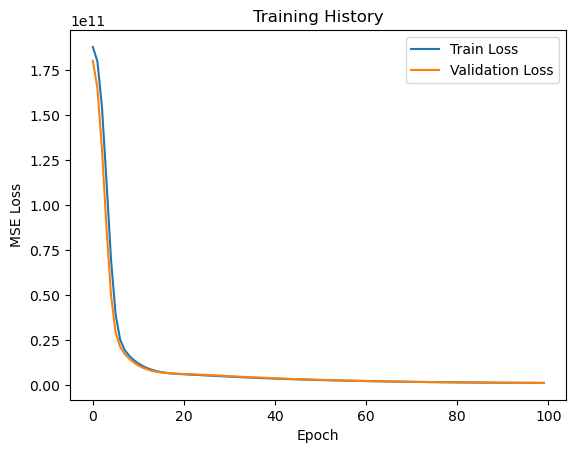

In [40]:
# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.show()

Key Observations:
Both Train and Validation Loss Drop Quickly (within the first ~15 epochs):

This means the model learned patterns in the data very quickly.

Good early convergence is often a sign your features are informative and well-scaled.

Smooth, Downward Curve:

No big spikes or erratic behavior = stable learning.

No Overfitting:

The training loss and validation loss stay close together.

If validation loss started rising while training loss continued falling, that would indicate overfitting — but you're not seeing that here.

✅ What This Means:
Your model is well-trained and generalizes well to unseen data.

The final MSE loss is very low, suggesting accurate predictions (which your MAE confirmed: ~$23.5k average error).

You likely don’t need more epochs — training flattens out by ~40.

***Predict Future Pricing***


In [41]:
# 1. Create future neighborhood-year combinations (2024–2035)
base_year = zillow_df["Year"].max()
future_years = list(range(2024, 2036))

In [42]:
# Extract unique neighborhoods and city
neighborhoods = zillow_df[["RegionID", "Neighborhood", "City"]].drop_duplicates()
future_df = neighborhoods.merge(pd.DataFrame({"Year": future_years}), how="cross")

In [43]:

# 2. One-hot encode Neighborhood and City
future_encoded = pd.get_dummies(future_df, columns=["Neighborhood", "City"])

In [44]:
# 3. Align future_encoded to training feature structure
# (match column order, fill missing dummy columns with 0)
for col in X.columns:
    if col not in future_encoded.columns:
        future_encoded[col] = 0
future_encoded = future_encoded[X.columns]

In [45]:
# 4. Scale future data using the same scaler
future_scaled = scaler.transform(future_encoded)

# 5. Predict
future_predictions = model.predict(future_scaled).flatten()

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [46]:
# 6. Attach predictions to the future_df
future_df["Predicted Home Value"] = np.round(future_predictions, 0)
future_df.head(10)

,RegionID,Neighborhood,City,Year,Predicted Home Value
0,6018,Montbello,Denver,2024,476308.0
1,6018,Montbello,Denver,2025,513369.0
2,6018,Montbello,Denver,2026,552070.0
3,6018,Montbello,Denver,2027,591549.0
4,6018,Montbello,Denver,2028,631387.0
5,6018,Montbello,Denver,2029,671787.0
6,6018,Montbello,Denver,2030,712712.0
7,6018,Montbello,Denver,2031,753661.0
8,6018,Montbello,Denver,2032,794823.0
9,6018,Montbello,Denver,2033,836414.0


In [47]:
# 7. Save to CSV
future_df.to_csv("Resources/keras_quarterly.csv", index=False)

**Pull neighborhoods with top 10 predicted growth**

In [48]:
# Filter 2024 and 2035 predictions
pred_2024 = future_df[future_df["Year"] == 2024][["RegionID", "Neighborhood", "Predicted Home Value"]]
pred_2035 = future_df[future_df["Year"] == 2035][["RegionID", "Neighborhood", "Predicted Home Value"]]

In [49]:
print("2024 rows:", pred_2024.shape[0])
print("2035 rows:", pred_2035.shape[0])

2024 rows: 76
2035 rows: 76


In [50]:
# Merge to calculate growth
growth_df = pred_2024.merge(
    pred_2035, on=["RegionID", "Neighborhood"], suffixes=("_2024", "_2035")
)

In [51]:
# Calculate growth
growth_df["Growth ($)"] = growth_df["Predicted Home Value_2035"] - growth_df["Predicted Home Value_2024"]
growth_df["Growth (%)"] = (growth_df["Growth ($)"] / growth_df["Predicted Home Value_2024"]) * 100

In [52]:
# Sort and show top 10 neighborhoods by absolute growth ($)
top10_growth = growth_df.sort_values(by="Growth ($)", ascending=False).head(10)
top10_growth.reset_index(drop=True, inplace=True)

top10_growth

,RegionID,Neighborhood,Predicted Home Value_2024,Predicted Home Value_2035,Growth ($),Growth (%)
0,268646,Country Club,1401043.0,1868284.0,467241.0,33.349510
1,268776,West Colfax,700379.0,1162459.0,462080.0,65.975708
2,268618,Belcaro,1218629.0,1678106.0,459477.0,37.704422
3,268740,South Park Hill,904933.0,1364002.0,459069.0,50.729614
4,268683,Jefferson Park,698495.0,1153684.0,455189.0,65.167114
5,268779,Whittier,707246.0,1161887.0,454641.0,64.283287
6,119762,Hilltop,1214312.0,1668525.0,454213.0,37.404968
7,268643,Congress Park,826618.0,1278993.0,452375.0,54.726006
8,403514,Sunnyside,678945.0,1129223.0,450278.0,66.320244
9,268672,Hampden South,565819.0,1015388.0,449569.0,79.454559


**Plot and Map**

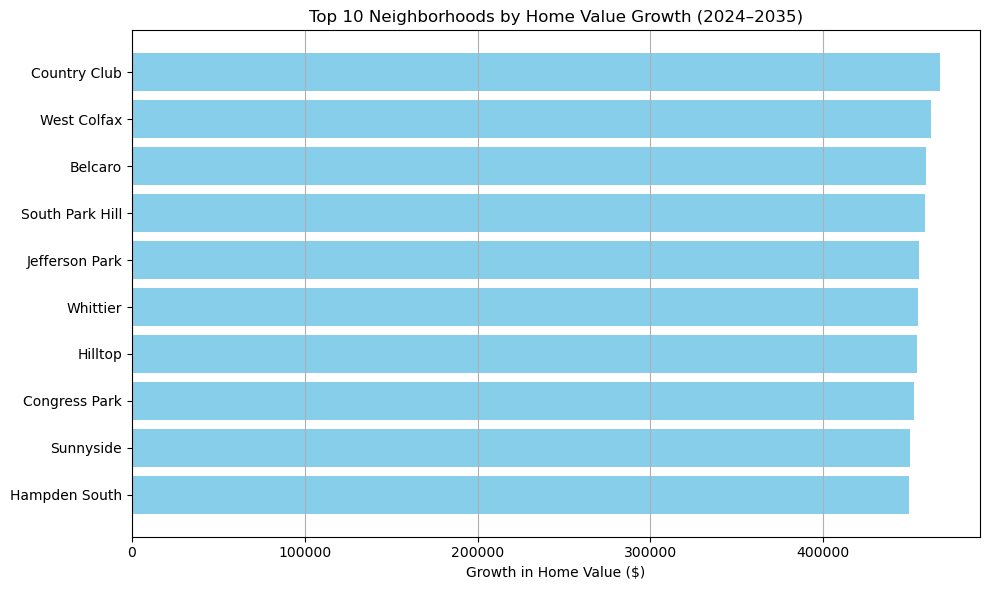

In [53]:
# Sort by $ growth (already done in top10_growth)
plt.figure(figsize=(10, 6))
plt.barh(top10_growth["Neighborhood"], top10_growth["Growth ($)"], color='skyblue')
plt.xlabel("Growth in Home Value ($)")
plt.title("Top 10 Neighborhoods by Home Value Growth (2024–2035)")
plt.gca().invert_yaxis()  # Largest on top
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

C:\Users\rober\AppData\Local\Temp\ipykernel_29860\1245681966.py:33: UserWarning:

Glyph 127750 (\N{CITYSCAPE AT DUSK}) missing from font(s) DejaVu Sans.

c:\Users\rober\anaconda3\envs\dev\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 127750 (\N{CITYSCAPE AT DUSK}) missing from font(s) DejaVu Sans.



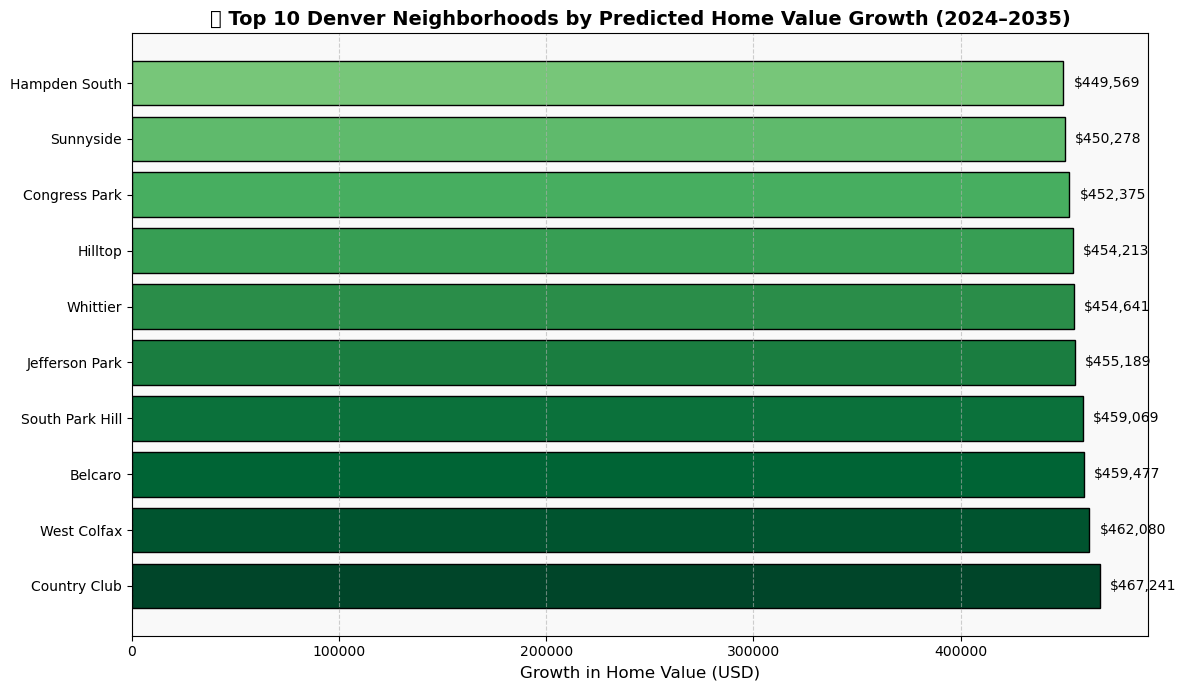

In [54]:
# Sort for better visual flow (just in case)
top10_sorted = top10_growth.sort_values(by="Growth ($)", ascending=True)

# Define color gradient (greens)
colors = plt.cm.YlGn(np.linspace(0.5, 1, len(top10_sorted)))

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top10_sorted["Neighborhood"],
    top10_sorted["Growth ($)"],
    color=colors,
    edgecolor='black'
)

# Add value labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5000,  # position to the right
        bar.get_y() + bar.get_height() / 2,
        f"${int(width):,}",
        va='center',
        fontsize=10,
        color='black'
    )

# Chart titles and labels
plt.xlabel("Growth in Home Value (USD)", fontsize=12)
plt.title("🌆 Top 10 Denver Neighborhoods by Predicted Home Value Growth (2024–2035)", fontsize=14, weight='bold')
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.gca().set_facecolor("#f9f9f9")
plt.gca().invert_yaxis()  # highest growth on top
plt.tight_layout()
plt.show()

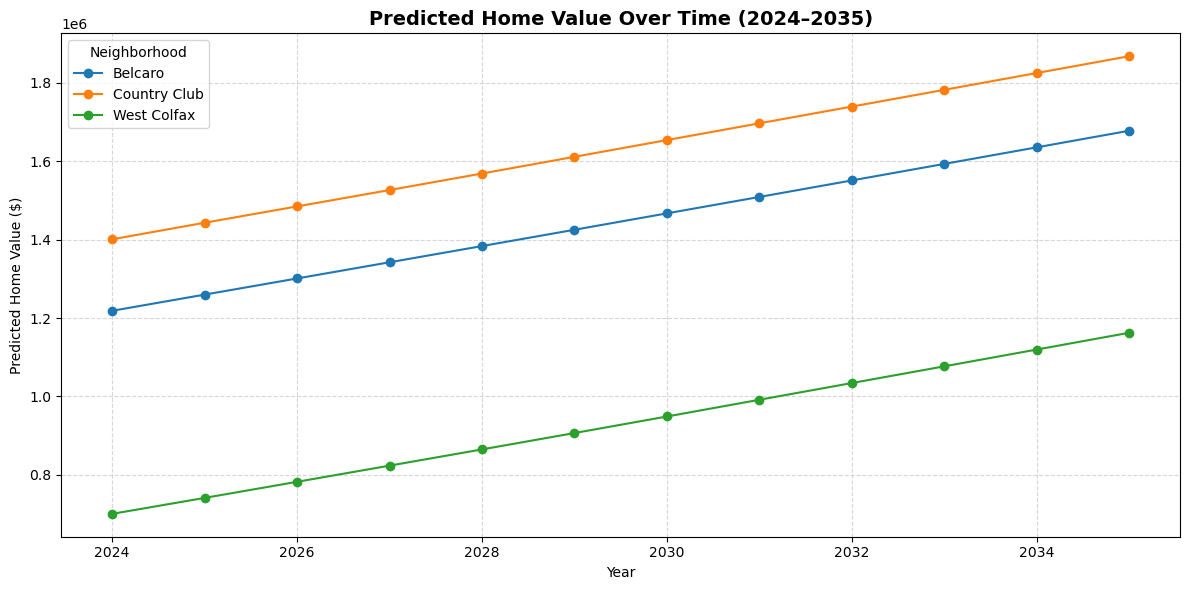

In [55]:
key_hoods = top10_growth["Neighborhood"].head(3).tolist()  # or pick your favorites
subset = future_df[future_df["Neighborhood"].isin(key_hoods)]

plt.figure(figsize=(12, 6))
for name, group in subset.groupby("Neighborhood"):
    plt.plot(group["Year"], group["Predicted Home Value"], marker='o', label=name)

plt.title("Predicted Home Value Over Time (2024–2035)", fontsize=14, weight='bold')
plt.xlabel("Year")
plt.ylabel("Predicted Home Value ($)")
plt.legend(title="Neighborhood")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\rober\AppData\Local\Temp\ipykernel_29860\100700701.py:47: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.

c:\Users\rober\anaconda3\envs\dev\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.



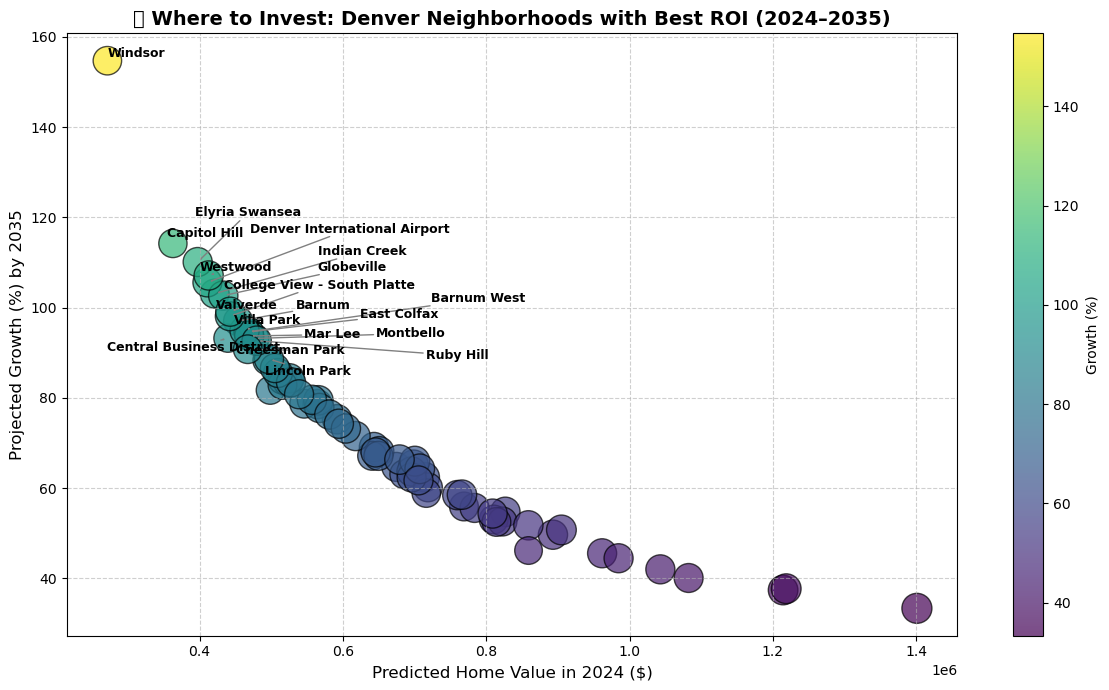

In [56]:
investment_df = growth_df.copy()

# Filter for best investment deals
price_median = investment_df["Predicted Home Value_2024"].median()
growth_threshold = investment_df["Growth (%)"].quantile(0.75)

# Filter top deals
top_deals = investment_df[
    (investment_df["Predicted Home Value_2024"] < price_median) &
    (investment_df["Growth (%)"] > growth_threshold)
]

# Plot base scatter
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    investment_df["Predicted Home Value_2024"],
    investment_df["Growth (%)"],
    s=investment_df["Growth ($)"] / 1000,
    c=investment_df["Growth (%)"],
    cmap="viridis",
    alpha=0.7,
    edgecolor="k"
)

# Filter and prepare label list
texts = []
for _, row in top_deals.iterrows():
    texts.append(
        plt.text(
            row["Predicted Home Value_2024"],
            row["Growth (%)"],
            row["Neighborhood"],
            fontsize=9,
            weight="bold"
        )
    )

# Automatically adjust labels to prevent overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=1))

# Final styling
plt.title("💰 Where to Invest: Denver Neighborhoods with Best ROI (2024–2035)", fontsize=14, weight='bold')
plt.xlabel("Predicted Home Value in 2024 ($)", fontsize=12)
plt.ylabel("Projected Growth (%) by 2035", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.colorbar(scatter, label="Growth (%)")
plt.tight_layout()
plt.show()

In [57]:
import plotly.express as px

# Create a copy of your best investment opportunities
investment_df["Dollar Growth"] = investment_df["Growth ($)"]
investment_df["Percent Growth"] = investment_df["Growth (%)"]
investment_df["2024 Value"] = investment_df["Predicted Home Value_2024"]

# Interactive scatter plot
fig = px.scatter(
    investment_df,
    x="2024 Value",
    y="Percent Growth",
    size="Dollar Growth",
    color="Percent Growth",
    hover_name="Neighborhood",
    hover_data={
        "2024 Value": ":$,",
        "Percent Growth": ":.1f",
        "Dollar Growth": ":$,"
    },
    color_continuous_scale="Viridis",
    title="💰 Where to Invest: Denver Neighborhoods with Best ROI (2024–2035)",
    labels={
        "2024 Value": "Predicted Home Value in 2024 ($)",
        "Percent Growth": "Projected Growth (%) by 2035"
    },
    height=650
)

fig.update_layout(
    title_font=dict(size=18),
    title_x=0.5,
    plot_bgcolor="#f9f9f9"
)

fig.show()
